# GRAD-CAM MODEL PREDICTION:

Grad-CAM (Gradient-weighted Class Activation Mapping) is used to visualize the regions of the image that contribute most to the model’s prediction.

Deep learning models like CNNs are often considered black-box models, as they do not provide explanations for their predictions.

In this project, Grad-CAM is applied to the selected VGG16 model to improve interpretability and understand how the model identifies tumor-related patterns.

In [1]:
import sys
print(sys.version)

3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]


In [2]:
!pip install torch torchvision numpy matplotlib opencv-python pillow

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   -- ------------------------------------- 8.7/123.0 MB 45.8 MB/s eta 0:00:03
   --- ------------------------------------ 11.0/123.0 MB 34.8 MB/s eta 0:00:04
   --- ------------------------------------ 11.5/123.0 MB 20.0 MB/s eta 0:00:06
   --- ------------------------------------ 11.8/123.0 MB 15.2 MB/s eta 0:00:08
   --- ------------------------------------ 12.1/123.0 MB 12.8 MB/s eta 0:00:09
   ---- ----------------------------------- 12.3/123.0 MB 11.4 MB/s eta 0:00:10
   ---- ----------------------------------- 12.8/123.0 MB 8.7 MB/s eta 0:00:13
   ---- ----------------------------------- 13.1/123.0 MB 7.9 MB/s eta 0:00:14
   ---- ----------------------------------- 13.4/123.0 MB 7.0 MB/s eta 0:00:16
   ---- ---------------

In [3]:
import torch
import torchvision
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("All libraries loaded ✅")

All libraries loaded ✅


In [4]:
import torch
print(torch.__version__)

2.12.1+cpu


In [15]:
import torch.nn as nn
from torchvision import models
from torchvision import transforms

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_path = "./VGG16 and MobileNetV2EfficientNetB0/vgg16_best.pth"

checkpoint = torch.load(checkpoint_path, map_location=device)

num_classes = len(checkpoint["class_to_idx"])

model = models.vgg16(weights=None)
model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

class_names = list(checkpoint["class_to_idx"].keys())

print("✅ Model loaded")

✅ Model loaded


In [11]:
target_layer = model.features[-1]

#We select the last convolutional layer of VGG16 (features[-1]).
#This layer contains high-level spatial features that the model uses for decision making.
#Grad-CAM works best on the last convolution layer because it preserves spatial information.


#### Apply GRAD-CAM
Grad-CAM is applied by computing gradients of the predicted class with respect to the feature maps.

These gradients are used to assign importance weights to each feature map, indicating which regions influenced the prediction most.

In [12]:
#Define GRAD-CAM

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.forward_hook)
        self.target_layer.register_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor):
        output = self.model(input_tensor)

        pred_class = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, pred_class].backward()

        gradients = self.gradients
        activations = self.activations

        pooled_gradients = torch.mean(gradients, dim=[0,2,3])

        for i in range(activations.shape[1]):
            activations[:, i, :, :] *= pooled_gradients[i]

        heatmap = torch.mean(activations, dim=1).squeeze()

        heatmap = np.maximum(heatmap.detach().cpu(), 0)
        heatmap /= torch.max(heatmap)

        return heatmap.numpy(), pred_class

In [13]:
import pandas as pd

df = pd.read_csv("./kavya_outputs/kavya_test_files.csv")

img_path = df["filepath"][0]   # first test image
print(img_path)

C:\Users\kavya.raghunathan\Desktop\Jupyter_Folder\processed_data\test\Cancer (1003).jpg


In [17]:
import pandas as pd

df = pd.read_csv("./kavya_outputs/kavya_test_files.csv")

print(df.head())

                                            filepath           filename split  \
0  C:\Users\kavya.raghunathan\Desktop\Jupyter_Fol...  Cancer (1003).jpg  test   
1  C:\Users\kavya.raghunathan\Desktop\Jupyter_Fol...  Cancer (1010).jpg  test   
2  C:\Users\kavya.raghunathan\Desktop\Jupyter_Fol...  Cancer (1019).jpg  test   
3  C:\Users\kavya.raghunathan\Desktop\Jupyter_Fol...  Cancer (1021).jpg  test   
4  C:\Users\kavya.raghunathan\Desktop\Jupyter_Fol...  Cancer (1025).JPG  test   

   label  target  
0  Tumor       1  
1  Tumor       1  
2  Tumor       1  
3  Tumor       1  
4  Tumor       1  


In [18]:
img_path = df["filepath"][0]
print(img_path)

C:\Users\kavya.raghunathan\Desktop\Jupyter_Folder\processed_data\test\Cancer (1003).jpg


In [19]:
import os
print(os.path.exists(img_path))


False


In [20]:
img_path = "./kavya_outputs/person2_custom_cnn_sample_predictions.png"

In [21]:
image = Image.open(img_path).convert("RGB")

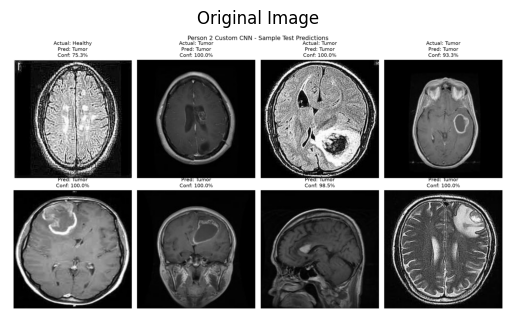

In [22]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

image = Image.open(img_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(device)

plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()



We apply Grad-CAM to compute a heatmap based on the predicted class.
The gradients help identify which regions of the image influenced the model's decision.

In [26]:
gradcam = GradCAM(model, target_layer)


heatmap, pred_class = gradcam.generate(input_tensor)

print("Predicted Class:", class_names[pred_class])


Predicted Class: Healthy


C:\Users\sanjana.mindi\AppData\Local\Temp\ipykernel_29436\2177299021.py:37: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  heatmap = np.maximum(heatmap.detach().cpu(), 0)


### GRAD-CAM HEAT MAP
The Grad-CAM heatmap is overlaid on the original image.

- Red regions indicate areas of high importance
- Blue regions indicate low importance

This helps visualize where the model focused to make its prediction


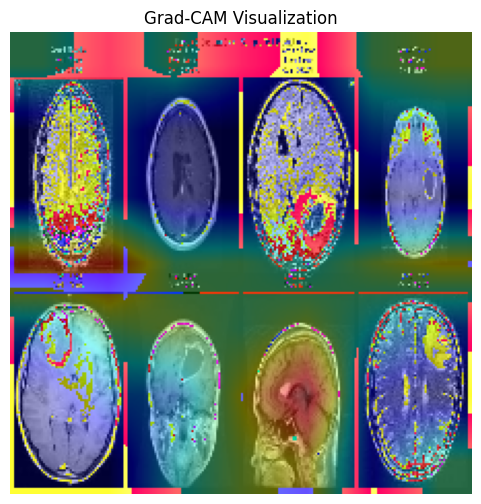

In [27]:
# Load original image using OpenCV
img = cv2.imread(img_path)
img = cv2.resize(img, (224, 224))

# Resize heatmap
heatmap = cv2.resize(heatmap, (224, 224))
heatmap = np.uint8(255 * heatmap)

# Apply color map
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Superimpose heatmap onto image
overlay = heatmap * 0.4 + img

# Display
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(overlay.astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Grad-CAM Visualization")
plt.show()


The Grad-CAM visualization highlights the regions in the image that contributed most to the model’s prediction.

For tumor predictions, the highlighted areas should correspond to abnormal or suspicious regions in the brain scan.

This indicates that the model is focusing on relevant features rather than random noise.

Thus, Grad-CAM improves model interpretability and increases trust in the prediction.

However, it is important to note that Grad-CAM only explains model behavior and does not medically confirm the presence of a tumor.